# 3-D Benchmark — Prompt U-Net vs nnInteractive

**Combined runner + results notebook.**

1. Configure paths and run parameters in **Section 1**.
2. Run the benchmark in **Section 2** (or skip to Section 3 to load existing results).
3. Analyse and visualise results in **Section 3**.

---
## Section 1 — Configuration

Edit the variables below before running anything else.

In [8]:
import sys, os

# ── Project root (adjust if notebook is moved) ──────────────────────────────
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# ── Model paths ─────────────────────────────────────────────────────────────
P_UNET_MODELS = [
    os.path.join(PROJECT_ROOT, 'training', 'p_unet_315.keras'),
    # add more paths here to evaluate multiple versions ...
]
NN_MODEL_DIR   = None    # None = auto-download from HuggingFace Hub

# ── Dataset .npz paths (ds_handler format) ──────────────────────────────────
NPZ_PATHS = [
    os.path.join(PROJECT_ROOT, 'data', 'test_data', 'Mouse_no_trachea.npz'),
    # add more paths here …
]

# ── Run parameters ──────────────────────────────────────────────────────────
RUNS_PER_VOL       = 1         # random prompts evaluated per volume
# MODES supported: 'ifl_ssf' (GT feedback + SSF), 'ifl' (GT only), 'ssf' (SSF only), 'none' (neither)
MODES              = 'ssf'   
MODALITY           = 'None'    # 'CT' or 'MRI' or None  (per-volume override from .npz if available, if not it takes this)
OUTPUT_THRESHOLD   = 0.5       # sigmoid threshold for P-UNet binary mask
SSF_THRESHOLD      = 0.40       # SSIM drop that triggers SSF refresh
GT_DICE_THRESHOLD  = 0.65      # IFL Dice threshold for GT correction
BATCH_SIZE         = 6         # slices per GPU forward pass 
WINDOW             = 10        # half-width for windowed Dice evaluation
MIN_PROMPT_PIXELS  = 50        # minimum foreground pixels for a prompt to be eligible
NN_DEVICE          = None      # None = auto-detect (CUDA if available, else CPU)

# ── Volumes to evaluate ─────────────────────────────────────────────────────
MAX_VOLUMES        = 1      # int (e.g. 3) to test subset, or None to evaluate all volumes

# ── Output directory (pkl + json are saved here) ────────────────────────────
# OUTPUT_DIR = os.path.join(os.getcwd())
OUTPUT_DIR = None # No need to save full pickles for this

print('Configuration loaded.')
print(f'  Models: {[os.path.basename(m) for m in P_UNET_MODELS]}')
print(f'  Modes : {MODES}')
print(f'  npz   : {[os.path.basename(p) for p in NPZ_PATHS]}')
print(f'  Max Volumes: {MAX_VOLUMES if MAX_VOLUMES else "All"}')
print(f'  Output: {OUTPUT_DIR}')

Configuration loaded.
  Models: ['p_unet_315.keras']
  Modes : ssf
  npz   : ['Mouse_no_trachea.npz']
  Max Volumes: 1
  Output: None


---
## Section 2 — Run Benchmark

Runs Prompt-UNet and nnInteractive on all configured datasets.  
Results are saved automatically to `OUTPUT_DIR` as `results_<timestamp>.pkl` and `results_<timestamp>_summary.json`.  

> ⚠️ **Skip this section** if you already have a `.pkl` file and only want to analyse results.


--- Single Run Visualizations (Model: p_unet_315.keras, Mode: ssf) ---

Loading Prompt-UNet: c:\Users\Paul\Desktop\Studium\prompt-unet\training\p_unet_315.keras (IFL: False, SSF: True)
[VolumeInference] Loading 'p_unet_315.keras' (norm='universal', modality_fallback=None, batch_size=3)
[VolumeInference] Graph compiled (warm-up done).

Loading nnInteractive …
[NNInteractiveInference] Downloading nnInteractive_v1.0 from nnInteractive/nnInteractive …


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

[NNInteractiveInference] Initialising session on device=cpu …
License reminder: The official nnInteractive checkpoint is licensed under Creative Commons Attribution Non Commercial Share Alike 4.0 (CC BY-NC-SA 4.0). See the license note in readme.md (# License).
[NNInteractiveInference] Ready.

Loading dataset: c:\Users\Paul\Desktop\Studium\prompt-unet\data\test_data\Mouse_no_trachea.npz

  Volume 1: Mouse_no_trachea__M02_004h | shape=(205, 104, 143) | modality=CT
    Run 1/1 … P-UNet vol=0.869 win=0.917 (12.4s)  |  nnInteract vol=0.767 win=0.843 (27.6s)

  BENCHMARK SUMMARY  (mode=ssf, n_runs=1)
  Prompt-UNet
    Volumetric Dice : 0.869 ± 0.000  [0.869 – 0.869]  median=0.869  n=1
    Window Dice     : 0.917 ± 0.000  [0.917 – 0.917]  median=0.917  n=1
  nnInteractive
    Volumetric Dice : 0.767 ± 0.000  [0.767 – 0.767]  median=0.767  n=1
    Window Dice     : 0.843 ± 0.000  [0.843 – 0.843]  median=0.843  n=1


Generating visualizations...


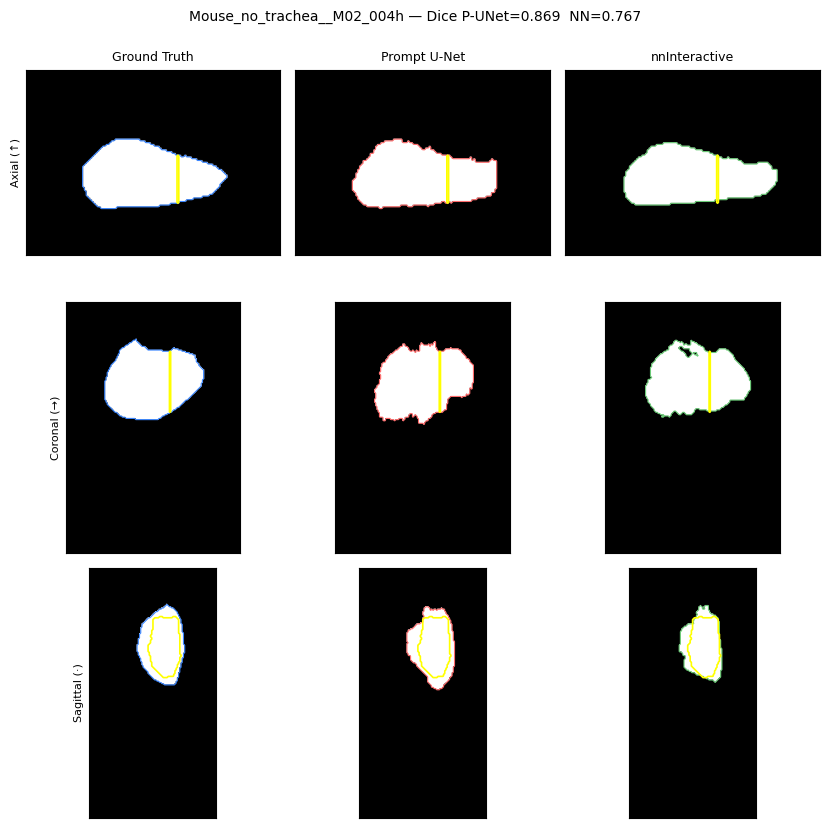

In [12]:
from inference.ssf import RelativeSSIMStrategy
from evaluation.benchmark_nninteractive.benchmark_3d import run_benchmark
import os
import numpy as np

# Use only the first model and first mode for the quick single run visualization
p_model = P_UNET_MODELS[0]

print(f"\n--- Single Run Visualizations (Model: {os.path.basename(p_model)}, Mode: {MODES}) ---")

records = run_benchmark(
    npz_paths           = NPZ_PATHS,
    p_unet_model        = p_model,
    nn_model_dir        = NN_MODEL_DIR,
    runs_per_vol        = RUNS_PER_VOL,
    mode                = MODES,
    modality            = MODALITY,
    output_threshold    = OUTPUT_THRESHOLD,
    ssf_strategy        = RelativeSSIMStrategy(SSF_THRESHOLD),
    gt_dice_threshold   = GT_DICE_THRESHOLD,
    window              = WINDOW,
    min_prompt_pixels   = MIN_PROMPT_PIXELS,
    max_volumes         = MAX_VOLUMES,
    output_dir          = OUTPUT_DIR, 
    nn_device           = NN_DEVICE,
    verbose             = True,
    return_predictions  = True,  # Return arrays for visualization
)

print(f"\nGenerating visualizations...")

from utils.viz_3d import render_mip_views
from IPython.display import display, Image

for record in records:
    vols = {
        "Ground Truth"  : record["seg_3d_binary"],
        "Prompt U-Net"   : record["p_unet_pred_vol"],
        "nnInteractive" : record["nn_pred_vol"],
    }
    title = f"{record['volume_id']} — Dice P-UNet={record['p_unet_vol_dice']:.3f}  NN={record['nn_vol_dice']:.3f}"

    # MIP projections (axial/coronal/sagittal × 3 columns) — fast, no skimage needed
    display(Image(data=render_mip_views(vols, anchor_prompt=record["initial_prompt_3d"], suptitle=title)))